# Eksperimen Depth dan Width
Eksperimen variasi width dan depth pada FFNN from scratch, menampilkan kurva loss train/val, lalu membandingkan hasil prediksi akhir.

In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
# %pip install scikit-learn
from sklearn.metrics import accuracy_score

sys.path.append(str(Path().resolve().parent))

from data_prep import load_and_preprocess_data
from ffnn import FFNN

In [6]:
np.random.seed(42)

data_path = Path.cwd().parent.parent / 'data' / 'global_student_placement_and_salary.csv'

X_train, y_train_raw, X_val, y_val_raw = load_and_preprocess_data(str(data_path))

num_classes = len(np.unique(y_train_raw))
is_binary = num_classes == 2

if is_binary:
    y_train = y_train_raw.reshape(-1, 1).astype(np.float64)
    y_val = y_val_raw.reshape(-1, 1).astype(np.float64)
    output_size = 1
    output_activation = 'sigmoid'
    loss_type = 'binary_crossentropy'
else:
    y_train = np.eye(num_classes)[y_train_raw]
    y_val = np.eye(num_classes)[y_val_raw]
    output_size = num_classes
    output_activation = 'softmax'
    loss_type = 'categorical_crossentropy'

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('num_classes =', num_classes, '| binary =', is_binary)

Train: (8000, 11) (8000, 1)
Val  : (2000, 11) (2000, 1)
num_classes = 2 | binary = True


## Konfigurasi Dasar dan Helper
Base hyperparameter dipakai sama untuk semua eksperimen agar perbandingan adil.

In [7]:
def predict_labels(model, X, is_binary_model):
    y_pred = model.forward(X)
    if is_binary_model:
        return (y_pred >= 0.5).astype(int).reshape(-1)
    return np.argmax(y_pred, axis=1)

def run_experiment(name, hidden_layers, X_train, y_train, X_val, y_val, y_val_raw, output_activation, output_size, loss_type, is_binary, epochs=60, batch_size=32, learning_rate=0.01):
    model = FFNN(
        layer_numbers_list=[X_train.shape[1]] + hidden_layers + [output_size],
        activation_function_list=['relu'] * len(hidden_layers) + [output_activation],
        weight_initial='normal',
    )

    history = model.fit(
        X=X_train,
        y=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epochs=epochs,
        verbose=0,
        loss_type=loss_type,
        reg_type=None,
        lambda_=0.0,
    )

    y_val_pred = predict_labels(model, X_val, is_binary)
    val_accuracy = accuracy_score(y_val_raw, y_val_pred)

    return {
        'name': name,
        'hidden_layers': hidden_layers,
        'history': history,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_accuracy': val_accuracy,
        'model': model,
    }

epochs = 60
batch_size = 32
learning_rate = 0.01

print('Base hyperparameter:')
print('epochs =', epochs)
print('batch_size =', batch_size)
print('learning_rate =', learning_rate)
print('hidden activation = relu')

Base hyperparameter:
epochs = 60
batch_size = 32
learning_rate = 0.01
hidden activation = relu


## Eksperimen Width (Depth Tetap)
Depth hidden layer ditetapkan 2 layer, lalu width divariasikan 3 opsi.

In [8]:
width_configs = {
    'width_small': [8, 8],
    'width_base': [16, 16],
    'width_large': [32, 32],
}

width_results = {}
for name, hidden_layers in width_configs.items():
    width_results[name] = run_experiment(
        name=name,
        hidden_layers=hidden_layers,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        y_val_raw=y_val_raw,
        output_activation=output_activation,
        output_size=output_size,
        loss_type=loss_type,
        is_binary=is_binary,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

print('Eksperimen width selesai.')

Eksperimen width selesai.


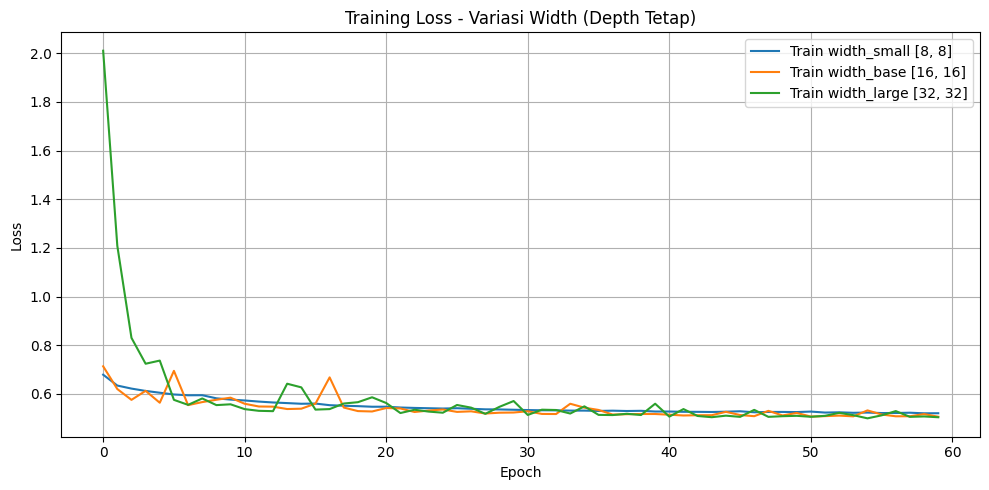

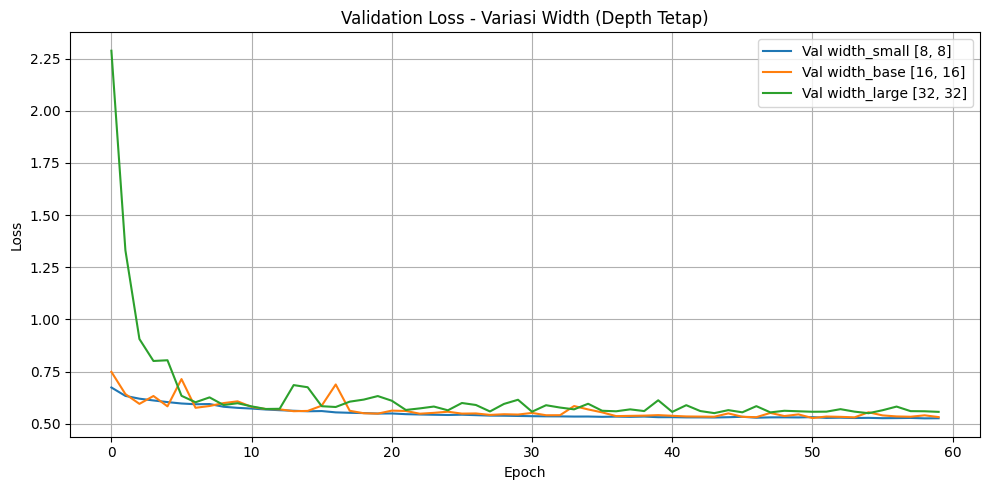

In [9]:
plt.figure(figsize=(10, 5))
for name, r in width_results.items():
    plt.plot(r['history']['train_loss'], label=f"Train {name} {r['hidden_layers']}")
plt.title('Training Loss - Variasi Width (Depth Tetap)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, r in width_results.items():
    plt.plot(r['history']['val_loss'], label=f"Val {name} {r['hidden_layers']}")
plt.title('Validation Loss - Variasi Width (Depth Tetap)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print('Ringkasan akhir eksperimen width')
print('config | hidden_layers | final_train_loss | final_val_loss | final_val_accuracy')
for name, r in width_results.items():
    print(f"{name:>11} | {str(r['hidden_layers']):>12} | {r['final_train_loss']:.6f} | {r['final_val_loss']:.6f} | {r['final_val_accuracy']:.6f}")

Ringkasan akhir eksperimen width
config | hidden_layers | final_train_loss | final_val_loss | final_val_accuracy
width_small |       [8, 8] | 0.520371 | 0.526566 | 0.735500
 width_base |     [16, 16] | 0.506022 | 0.532153 | 0.723000
width_large |     [32, 32] | 0.503849 | 0.557134 | 0.710500


## Eksperimen Depth (Width Tetap)
Width hidden layer ditetapkan 16 neuron per layer, lalu depth divariasikan 3 opsi.

In [11]:
depth_configs = {
    'depth_1': [16],
    'depth_2': [16, 16],
    'depth_3': [16, 16, 16],
}

depth_results = {}
for name, hidden_layers in depth_configs.items():
    depth_results[name] = run_experiment(
        name=name,
        hidden_layers=hidden_layers,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        y_val_raw=y_val_raw,
        output_activation=output_activation,
        output_size=output_size,
        loss_type=loss_type,
        is_binary=is_binary,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
    )

print('Eksperimen depth selesai.')

Eksperimen depth selesai.


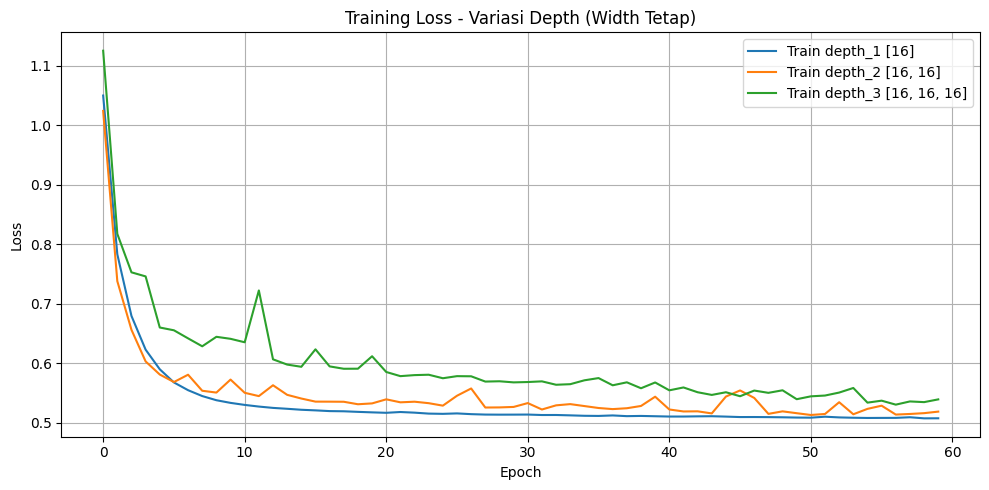

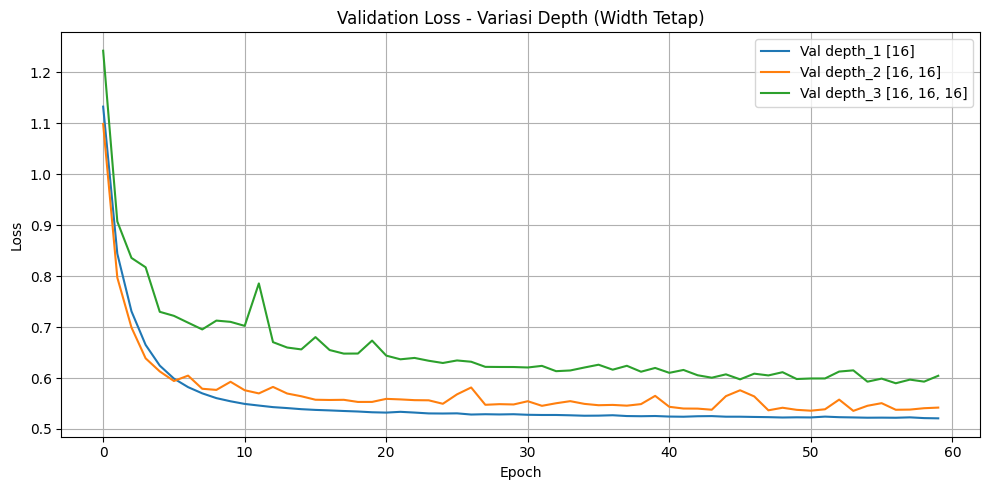

In [12]:
plt.figure(figsize=(10, 5))
for name, r in depth_results.items():
    plt.plot(r['history']['train_loss'], label=f"Train {name} {r['hidden_layers']}")
plt.title('Training Loss - Variasi Depth (Width Tetap)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, r in depth_results.items():
    plt.plot(r['history']['val_loss'], label=f"Val {name} {r['hidden_layers']}")
plt.title('Validation Loss - Variasi Depth (Width Tetap)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
print('Ringkasan akhir eksperimen depth')
print('config | hidden_layers | final_train_loss | final_val_loss | final_val_accuracy')
for name, r in depth_results.items():
    print(f"{name:>8} | {str(r['hidden_layers']):>12} | {r['final_train_loss']:.6f} | {r['final_val_loss']:.6f} | {r['final_val_accuracy']:.6f}")

Ringkasan akhir eksperimen depth
config | hidden_layers | final_train_loss | final_val_loss | final_val_accuracy
 depth_1 |         [16] | 0.507223 | 0.520795 | 0.736500
 depth_2 |     [16, 16] | 0.518423 | 0.541885 | 0.732000
 depth_3 | [16, 16, 16] | 0.539004 | 0.604381 | 0.689000


In [14]:
all_results = []
for group, result_dict in [('width', width_results), ('depth', depth_results)]:
    for name, r in result_dict.items():
        all_results.append((group, name, r['hidden_layers'], r['final_train_loss'], r['final_val_loss'], r['final_val_accuracy']))

best_by_acc = max(all_results, key=lambda x: x[5])
best_by_val_loss = min(all_results, key=lambda x: x[4])

print('Best by validation accuracy:')
print(f'group={best_by_acc[0]}, config={best_by_acc[1]}, hidden_layers={best_by_acc[2]}, val_acc={best_by_acc[5]:.6f}')

print('Best by validation loss:')
print(f'group={best_by_val_loss[0]}, config={best_by_val_loss[1]}, hidden_layers={best_by_val_loss[2]}, val_loss={best_by_val_loss[4]:.6f}')

Best by validation accuracy:
group=depth, config=depth_1, hidden_layers=[16], val_acc=0.736500
Best by validation loss:
group=depth, config=depth_1, hidden_layers=[16], val_loss=0.520795
